# Fake-news data — notebook QA vs pipeline

On-the-fly **QA and summary reports** on pipeline artefacts (tables and plots the scripts do not print). How to **build** those artefacts: `pipeline/README.md` and `pipeline/DATASETS_OVERVIEW.md`.

| # | Focus | What this notebook does |
|---|--------|-------------------------|
| — | — | Set `ROOT`, import libs |
| 1 | Unified `fakenews.tsv` | Load `data/fakenews.tsv`; nulls, dupes, counts, plots |
| 2 | FNN crawl inputs | Index CSVs vs `news content.json`; summarize `crawl_failures.jsonl` |
| 3 | Fakeddit multimodal TSVs | Chunk-scan row counts, bad URLs, etc. |
| 4 | Consolidated TSV vs FNN crawl | Compare FNN rows in TSV to JSON count from section 2 (failure-log filtering) |
| 5 | Cohort image fetch | Read `cohort_image_fetch.log` — status, crosstabs, failure strings |
| 6 | Gated export | Profile `data/fake_news_final.tsv` |

**Paths:** unified table is **`data/fakenews.tsv`**. Cohort images and logs live under **`data/processed/images/`** (not a copy of the TSV there). First code cell sets **`ROOT`** (works from `notebooks/` or project root).

**Deps:** `pandas`, `matplotlib`, `seaborn`.


In [10]:
import json
import os
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

# Project root (notebook in notebooks/ or cwd already root)
_cwd = Path.cwd()
ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
if not (ROOT / "data").is_dir():
    ROOT = _cwd  # fallback
os.chdir(ROOT)
print("ROOT =", ROOT.resolve())

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 4)


ROOT = /Users/markphillips/Downloads/MSC Project


## 1. Consolidated `fakenews.tsv`

**Input:** `data/fakenews.tsv` (~700k rows; ~1–2 GB RAM).


rows: 696676 cols: ['dataset', 'sample_id', 'split_official', 'domain', 'label_binary', 'label_fine', 'image_ref', 'has_image_ref', 'provenance', 'image_option1_validity_score', 'image_option1_qc_flags', 'image_option1_training_eligible', 'cohort_image_fetch_status', 'cohort_image_local_path', 'cohort_image_fetch_detail', 'cohort_multimodal_image_ok']


,dataset,sample_id,split_official,domain,label_binary,label_fine,image_ref,has_image_ref,provenance,image_option1_validity_score,image_option1_qc_flags,image_option1_training_eligible,cohort_image_fetch_status,cohort_image_local_path,cohort_image_fetch_detail,cohort_multimodal_image_ok
0,fakeddit,fd:awxhir,train,mildlyinteresting,1,0,https://external-preview.redd.it/WylDbZrnbvZdB...,true,data/processed/fakeddit/v2_text_metadata/multi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,fakeddit,fd:98pbid,train,pareidolia,0,2,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,true,data/processed/fakeddit/v2_text_metadata/multi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fakeddit,fd:6f2cy5,train,neutralnews,1,0,https://external-preview.redd.it/6fNhdbc6K1vFA...,true,data/processed/fakeddit/v2_text_metadata/multi...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696676 entries, 0 to 696675
Data columns (total 16 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   dataset                          696676 non-null  object
 1   sample_id                        696676 non-null  object
 2   split_official                   682661 non-null  object
 3   domain                           696676 non-null  object
 4   label_binary                     696676 non-null  object
 5   label_fine                       682661 non-null  object
 6   image_ref                        694628 non-null  object
 7   has_image_ref                    696676 non-null  object
 8   provenance                       696676 non-null  object
 9   image_option1_validity_score     50000 non-null   object
 10  image_option1_qc_flags           664 non-null     object
 11  image_option1_training_eligible  50000 non-null   object
 12  cohort_image_fet

None

,null,empty_or_blank
dataset,0,0
sample_id,0,0
split_official,14015,14015
domain,0,0
label_binary,0,0
label_fine,14015,14015
image_ref,2048,2048
has_image_ref,0,0
provenance,0,0
image_option1_validity_score,646676,646676


duplicate sample_id rows: 0


dataset
fakeddit       682661
fakenewsnet     14015
Name: count, dtype: int64

split_official
train         564000
validation     59342
test           59319
NaN            14015
Name: count, dtype: int64

has_image_ref
true     694628
false      2048
Name: count, dtype: int64

,count,with_image_ref,rate
dataset,,,
fakeddit,682661,680669,0.997082
fakenewsnet,14015,13959,0.996004


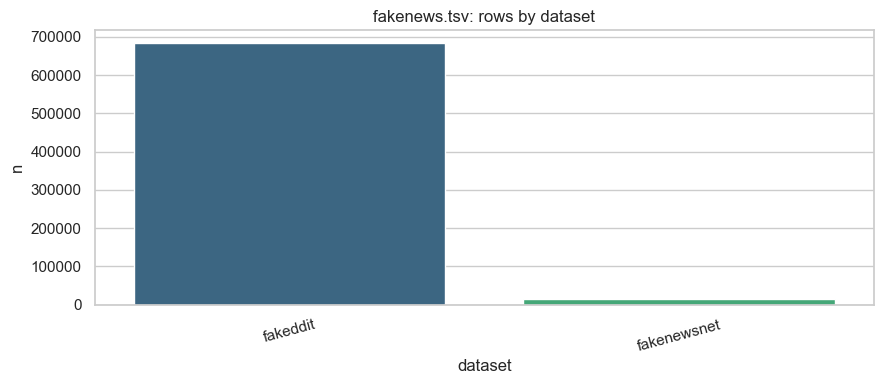

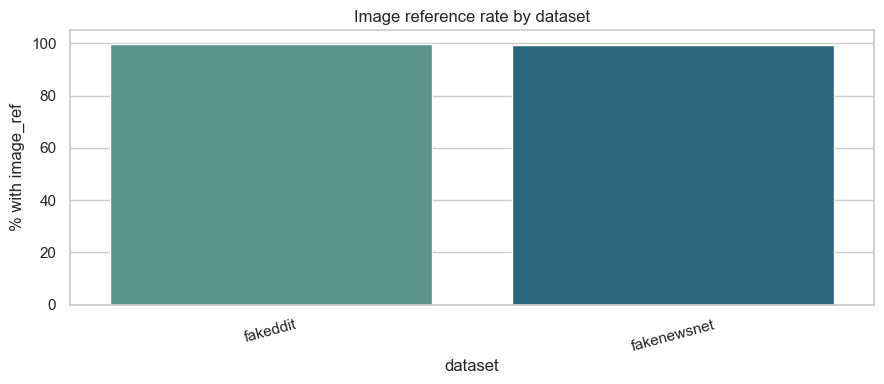

In [11]:
# --- Load consolidated `data/fakenews.tsv` (unified table is not stored under processed/images/) ---
FNEW = ROOT / "data" / "fakenews.tsv"
assert FNEW.is_file(), f"Missing {FNEW} — build the unified table per pipeline docs (README / DATASETS_OVERVIEW)."

df = pd.read_csv(FNEW, sep="\t", dtype=str, low_memory=False)
print("rows:", len(df), "cols:", list(df.columns))
display(df.head(3))
display(df.info(memory_usage="deep"))

# --- Null / blank rates ---
empty = {}
for c in df.columns:
    s = df[c].fillna("").astype(str).str.strip()
    empty[c] = {"null": int(df[c].isna().sum()), "empty_or_blank": int((s == "").sum())}
display(pd.DataFrame(empty).T)

# --- Duplicates and keys ---
dup_sid = df["sample_id"].duplicated().sum()
print("duplicate sample_id rows:", int(dup_sid))
for col in ["dataset", "split_official", "has_image_ref"]:
    if col in df.columns:
        display(df[col].value_counts(dropna=False))

df["has_image_ref_bool"] = df["has_image_ref"].str.lower().eq("true")
ref_by_dataset = df.groupby("dataset", observed=True).agg(
    count=("has_image_ref_bool", "count"),
    with_image_ref=("has_image_ref_bool", "sum"),
    rate=("has_image_ref_bool", "mean"),
)
display(ref_by_dataset)

# --- Plots (long-form DataFrames — seaborn 0.13+ barplot API) ---
_rbd = ref_by_dataset.reset_index().rename(columns={"count": "n"})
rows_by_ds = pd.DataFrame({"dataset": _rbd["dataset"], "n": _rbd["n"]})
fig, ax = plt.subplots()
sns.barplot(
    data=rows_by_ds,
    x="dataset",
    y="n",
    hue="dataset",
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("fakenews.tsv: rows by dataset")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

_rbd2 = ref_by_dataset.reset_index()
rate_pct = pd.DataFrame(
    {"dataset": _rbd2["dataset"], "pct": _rbd2["rate"].astype("float64") * 100.0}
)
fig, ax = plt.subplots()
sns.barplot(
    data=rate_pct,
    x="dataset",
    y="pct",
    hue="dataset",
    palette="crest",
    legend=False,
    ax=ax,
)
ax.set_ylim(0, 105)
ax.set_ylabel("% with image_ref")
ax.set_title("Image reference rate by dataset")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


## 2. FakeNewsNet crawl vs index

**Pipeline:** crawl from `01_acquire_fakenewsnet_crawl.py`; optional QA `03_*`. **Notebook:** compare index CSV row counts to `data/processed/fakenewsnet/**/news content.json`; parse `crawl_failures.jsonl` (append events, not unique rows per line).


,source,label,index_rows,succeeded_json,gap_index_minus_ok
0,politifact,fake,432,159,273
1,politifact,real,624,193,431
2,gossipcop,fake,5323,3261,2062
3,gossipcop,real,16817,10535,6282


FNN dataset dir exists: True  collected exists: True


,reason,append_events,unique_story_keys
0,no_article,8426,8426
1,empty_body,755,755


,split,append_events,unique_news_id
0,gossipcop/fake,2062,2062
1,gossipcop/real,6403,6403
2,politifact/fake,285,285
3,politifact/real,431,431


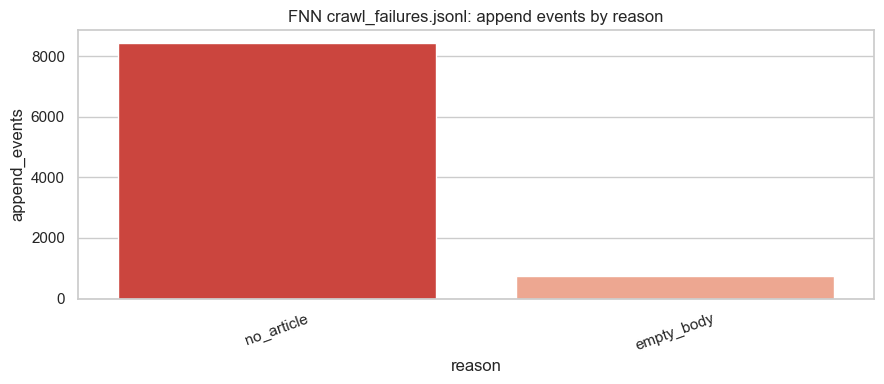

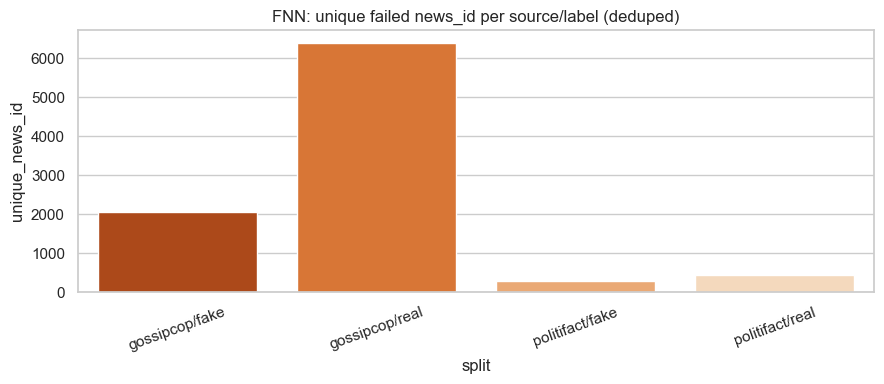

In [12]:
FNN_DATASET = ROOT / "pipeline" / "fakenewsnet" / "dataset"
FNN_COLLECTED = ROOT / "data" / "processed" / "fakenewsnet"
FAIL_LOG = FNN_COLLECTED / "crawl_failures.jsonl"

splits = [
    ("politifact", "fake"),
    ("politifact", "real"),
    ("gossipcop", "fake"),
    ("gossipcop", "real"),
]


def csv_rows(p: Path) -> int:
    if not p.is_file():
        return 0
    with p.open(encoding="utf-8", newline="") as f:
        return max(0, sum(1 for _ in f) - 1)


def count_news_json(collected: Path, src: str, lab: str) -> int:
    d = collected / src / lab
    if not d.is_dir():
        return 0
    return sum(1 for x in d.iterdir() if x.is_dir() and (x / "news content.json").is_file())


fnn_rows = []
for src, lab in splits:
    idx = csv_rows(FNN_DATASET / f"{src}_{lab}.csv")
    ok = count_news_json(FNN_COLLECTED, src, lab)
    fnn_rows.append({"source": src, "label": lab, "index_rows": idx, "succeeded_json": ok})

fnn_index_df = pd.DataFrame(fnn_rows)
fnn_index_df["gap_index_minus_ok"] = fnn_index_df["index_rows"] - fnn_index_df["succeeded_json"]
display(fnn_index_df)
print("FNN dataset dir exists:", FNN_DATASET.is_dir(), " collected exists:", FNN_COLLECTED.is_dir())

# --- crawl_failures.jsonl (one JSON object per append; same news_id may repeat) ---
reason_ev = Counter()
split_ev = Counter()
reason_unique = defaultdict(set)
split_unique = defaultdict(set)

if FAIL_LOG.is_file():
    with FAIL_LOG.open(encoding="utf-8") as fp:
        for line in fp:
            line = line.strip()
            if not line:
                continue
            try:
                o = json.loads(line)
            except json.JSONDecodeError:
                continue
            if o.get("event") != "failed":
                continue
            r = o.get("reason", "?")
            nsrc = o.get("news_source")
            nlab = o.get("label")
            nid = o.get("news_id")
            reason_ev[r] += 1
            if nsrc and nlab and nid is not None:
                sk = f"{nsrc}/{nlab}"
                split_ev[sk] += 1
                reason_unique[r].add((nsrc, nlab, str(nid)))
                split_unique[sk].add(str(nid))
else:
    print("No failure log at", FAIL_LOG)

fail_summary = pd.DataFrame(
    [{"reason": k, "append_events": v, "unique_story_keys": len(reason_unique[k])} for k, v in reason_ev.items()]
)
if not fail_summary.empty:
    fail_summary = fail_summary.sort_values("append_events", ascending=False)
display(fail_summary)

split_fail_df = pd.DataFrame(
    [{"split": k, "append_events": split_ev[k], "unique_news_id": len(split_unique[k])} for k in sorted(split_ev)]
)
display(split_fail_df)

# --- Plots ---
if not fail_summary.empty:
    fig, ax = plt.subplots()
    sns.barplot(
        data=fail_summary,
        x="reason",
        y="append_events",
        ax=ax,
        hue="reason",
        palette="Reds_r",
        legend=False,
    )
    ax.set_title("FNN crawl_failures.jsonl: append events by reason")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    if not split_fail_df.empty:
        fig, ax = plt.subplots()
        sns.barplot(
            data=split_fail_df,
            x="split",
            y="unique_news_id",
            ax=ax,
            hue="split",
            palette="Oranges_r",
            legend=False,
        )
        ax.set_title("FNN: unique failed news_id per source/label (deduped)")
        plt.xticks(rotation=20)
        plt.tight_layout()
        plt.show()


## 3. Fakeddit multimodal TSVs

**Pipeline:** metadata from `02_acquire_fakeddit_metadata.py`. **Notebook:** chunked scan of `multimodal_only_samples/*.tsv` (rows, bad `image_url`, `hasImage`, `clean_title` if present).


,split_file,path,rows,image_url_na,image_url_blank,image_url_missing_rate,hasImage_top,clean_title_na,clean_title_blank,status
0,train,/Users/markphillips/Downloads/MSC Project/data...,564000,1534,1534,0.005440,{'True': 564000},0,0,ok
1,validation,/Users/markphillips/Downloads/MSC Project/data...,59342,173,173,0.005831,{'True': 59342},0,0,ok
2,test,/Users/markphillips/Downloads/MSC Project/data...,59319,156,156,0.005260,{'True': 59319},0,0,ok


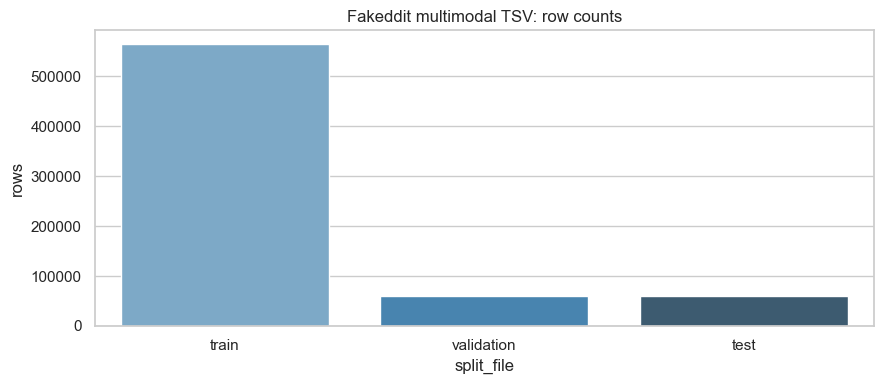

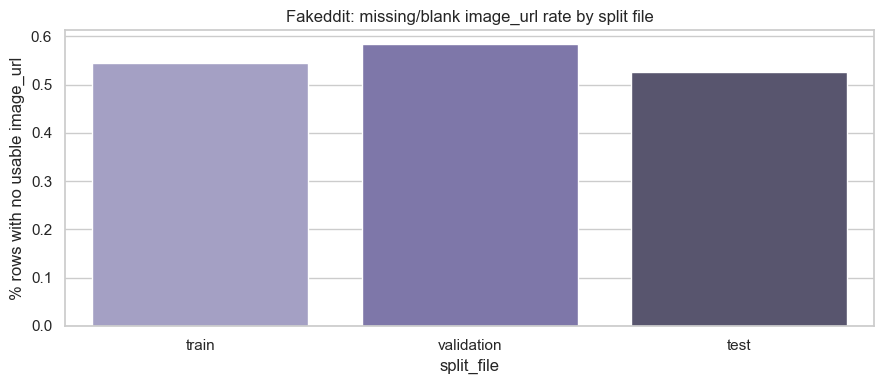

In [13]:
FAKE_META = ROOT / "data" / "processed" / "fakeddit" / "v2_text_metadata"
MM_DIR = FAKE_META / "multimodal_only_samples"
mm_files = [
    ("train", MM_DIR / "multimodal_train.tsv"),
    ("validation", MM_DIR / "multimodal_validate.tsv"),
    ("test", MM_DIR / "multimodal_test_public.tsv"),
]


def scan_fakeddit_tsv(path: Path, chunksize: int = 80_000):
    if not path.is_file():
        return None
    rows = 0
    blank_url = 0
    na_url = 0
    has_img_counts = Counter()
    blank_title = 0
    na_title = 0
    for chunk in pd.read_csv(path, sep="\t", chunksize=chunksize, dtype=str, on_bad_lines="warn"):
        rows += len(chunk)
        if "image_url" in chunk.columns:
            s = chunk["image_url"]
            na_url += int(s.isna().sum())
            blank_url += int(s.fillna("").astype(str).str.strip().eq("").sum())
        if "hasImage" in chunk.columns:
            for v in chunk["hasImage"].fillna("(null)").astype(str):
                has_img_counts[v] += 1
        if "clean_title" in chunk.columns:
            t = chunk["clean_title"]
            na_title += int(t.isna().sum())
            blank_title += int(t.fillna("").astype(str).str.strip().eq("").sum())
    return {
        "rows": rows,
        "image_url_na": na_url,
        "image_url_blank": blank_url,
        "image_url_missing_rate": (na_url + blank_url) / rows if rows else 0,
        "hasImage_top": dict(has_img_counts.most_common(8)),
        "clean_title_na": na_title,
        "clean_title_blank": blank_title,
    }


fd_stats = []
for split_name, fp in mm_files:
    r = scan_fakeddit_tsv(fp)
    if r is None:
        fd_stats.append({"split_file": split_name, "path": str(fp), "status": "missing"})
    else:
        fd_stats.append({"split_file": split_name, "path": str(fp), **r, "status": "ok"})

fd_df = pd.DataFrame(fd_stats)
display(fd_df)

ok = fd_df[fd_df["status"] == "ok"]
if not ok.empty:
    fig, ax = plt.subplots()
    x = ok["split_file"]
    sns.barplot(x=x, y=ok["rows"].astype(float), ax=ax, hue=x, palette="Blues_d", legend=False)
    ax.set_title("Fakeddit multimodal TSV: row counts")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots()
    sns.barplot(x=x, y=ok["image_url_missing_rate"].astype(float) * 100, ax=ax, hue=x, palette="Purples_d", legend=False)
    ax.set_ylabel("% rows with no usable image_url")
    ax.set_title("Fakeddit: missing/blank image_url rate by split file")
    plt.tight_layout()
    plt.show()


## 4. FNN rows: TSV vs crawl tree

**Pipeline:** consolidation drops FNN keys listed in `crawl_failures.jsonl`. **Notebook:** compare FNN row count in `fakenews.tsv` to succeeded JSON count from section 2.


In [14]:
fnn_in_tsv = df[df["dataset"] == "fakenewsnet"]
n_tsv = len(fnn_in_tsv)
n_json = int(fnn_index_df["succeeded_json"].sum())
print("FNN rows in fakenews.tsv:", n_tsv)
print("FNN news content.json files on disk:", n_json)
print("Difference (typically failure-log exclusions):", n_json - n_tsv)


FNN rows in fakenews.tsv: 14015
FNN news content.json files on disk: 14148
Difference (typically failure-log exclusions): 133


## 5. Cohort image fetch log

**Pipeline:** `06_cohort_fetch_images.py` (and optionally `07_cohort_dedupe_fetch_log.py`). **Notebook:** read `data/processed/images/cohort_image_fetch.log` — status counts, dataset crosstab, top failure strings.


Rows: 75,694


,ts_utc,status,dataset,sample_id,image_ref,local_path,detail,status_l
0,2026-04-05T18:33:35Z,ok,fakeddit,fd:8e0w8f,https://external-preview.redd.it/xRHrUMDvgfHM1...,data/processed/images/fd_8e0w8f.jpg,NaN,ok
1,2026-04-05T18:33:36Z,ok,fakeddit,fd:17o36f,https://external-preview.redd.it/Zumc3MqhV819z...,data/processed/images/fd_17o36f.jpg,NaN,ok
2,2026-04-05T18:33:36Z,ok,fakeddit,fd:awjc2a,https://preview.redd.it/5tqrt9xpeqj21.jpg?widt...,data/processed/images/fd_awjc2a.jpg,NaN,ok
3,2026-04-05T18:33:36Z,fail,fakeddit,fd:cfeye60,http://i.imgur.com/2BdEUtA.jpg,NaN,reddit_placeholder_sha256,fail
4,2026-04-05T18:33:36Z,ok,fakeddit,fd:19um67,https://external-preview.redd.it/qG-TsNeSE0TR1...,data/processed/images/fd_19um67.jpg,NaN,ok
5,2026-04-05T18:33:37Z,ok,fakeddit,fd:82naz4,https://external-preview.redd.it/WTHUI0DpEKAAF...,data/processed/images/fd_82naz4.jpg,NaN,ok
6,2026-04-05T18:33:37Z,ok,fakeddit,fd:dfe4m4,https://external-preview.redd.it/YdnAZB0koytXC...,data/processed/images/fd_dfe4m4.jpg,NaN,ok
7,2026-04-05T18:33:37Z,ok,fakeddit,fd:99rnyg,https://external-preview.redd.it/vajzn7kl1dKDM...,data/processed/images/fd_99rnyg.jpg,NaN,ok
8,2026-04-05T18:33:37Z,ok,fakeddit,fd:6s747m,https://external-preview.redd.it/ESPM-tTuK3wer...,data/processed/images/fd_6s747m.png,NaN,ok
9,2026-04-05T18:33:38Z,ok,fakeddit,fd:44ipz1,https://external-preview.redd.it/0XK57sqXNl6oX...,data/processed/images/fd_44ipz1.jpg,NaN,ok


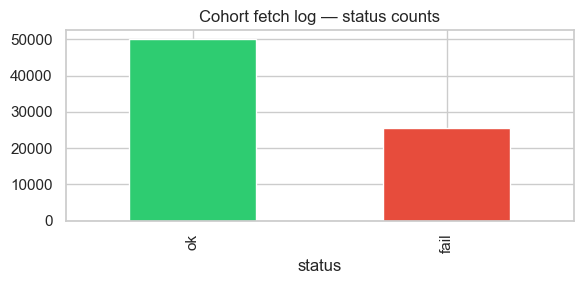


By dataset × status:


status_l,fail,ok
dataset,,
fakeddit,25561,48410
fakenewsnet,133,1590



Top failure detail strings:


detail
reddit_placeholder_sha256    20776
HTTPError                     3751
ConnectionError               1081
too_small                       39
pil_verify_failed               39
SSLError                         5
InvalidURL                       1
ChunkedEncodingError             1
TooManyRedirects                 1
Name: count, dtype: int64

In [15]:
FETCH_LOG = ROOT / "data/processed/images/cohort_image_fetch.log"
if not FETCH_LOG.is_file():
    print(f"Missing {FETCH_LOG} — run pipeline/06_cohort_fetch_images.py first.")
else:
    df_log = pd.read_csv(FETCH_LOG, sep="\t", dtype=str)
    df_log["status_l"] = df_log["status"].str.strip().str.lower()
    print(f"Rows: {len(df_log):,}")
    display(df_log.head(30))
    fig, ax = plt.subplots(figsize=(6, 3))
    vc = df_log["status_l"].value_counts()
    colors: dict[str, str] = {"ok": "#2ecc71", "fail": "#e74c3c"}
    bar_colors = [colors.get(str(x), "#95a5a6") for x in vc.index]
    vc.plot(kind="bar", ax=ax, color=bar_colors)
    ax.set_title("Cohort fetch log — status counts")
    ax.set_xlabel("status")
    plt.tight_layout()
    plt.show()
    if "dataset" in df_log.columns:
        print("\nBy dataset × status:")
        ct = pd.crosstab(df_log["dataset"].fillna("(blank)"), df_log["status_l"], margins=False)
        display(ct)
    fail = df_log[df_log["status_l"] == "fail"]
    if not fail.empty:
        print("\nTop failure detail strings:")
        display(
            pd.Series(fail["detail"])
            .fillna("(empty)")
            .astype(str)
            .str.slice(0, 120)
            .value_counts()
            .head(15)
        )


## 6. Gated export `fake_news_final.tsv`

**Pipeline:** image checks in `08_cohort_image_validation.py`, merges `09`/`10`, export `11_cohort_export_final_tsv.py`. **Notebook:** row counts, validity score distribution, quick preview.


Rows: 48,878  Columns: 16

Validity score — min 75, max 100, mean 94.81, median 96


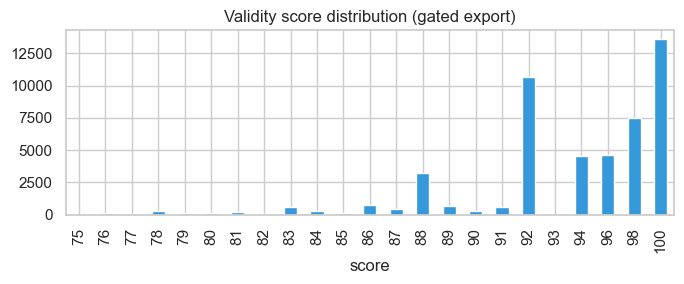


By dataset:


dataset
fakeddit       47458
fakenewsnet     1420
Name: count, dtype: int64


By label_binary:


label_binary
1    26559
0    22319
Name: count, dtype: int64

,dataset,sample_id,split_official,domain,label_binary,label_fine,image_ref,has_image_ref,provenance,image_option1_validity_score,image_option1_qc_flags,image_option1_training_eligible,cohort_image_fetch_status,cohort_image_local_path,cohort_image_fetch_detail,cohort_multimodal_image_ok
0,fakeddit,fd:2vkbtj,train,nottheonion,1,0.0,https://external-preview.redd.it/FQ-J9OIPFRpqi...,True,data/processed/fakeddit/v2_text_metadata/multi...,98,,True,ok,data/processed/images/fd_2vkbtj.jpg,,True
1,fakeddit,fd:98vrcq,train,fakehistoryporn,0,2.0,https://preview.redd.it/31aw9wjucah11.jpg?widt...,True,data/processed/fakeddit/v2_text_metadata/multi...,88,,True,ok,data/processed/images/fd_98vrcq.jpg,,True
2,fakeddit,fd:bjmfr7,train,mildlyinteresting,1,0.0,https://preview.redd.it/c9ri4lj3znv21.jpg?widt...,True,data/processed/fakeddit/v2_text_metadata/multi...,100,,True,ok,data/processed/images/fd_bjmfr7.jpg,,True
3,fakeddit,fd:c2mktw,train,mildlyinteresting,1,0.0,https://preview.redd.it/dfhs2vmumd531.jpg?widt...,True,data/processed/fakeddit/v2_text_metadata/multi...,94,,True,ok,data/processed/images/fd_c2mktw.jpg,,True
4,fakeddit,fd:212vud,train,pareidolia,0,2.0,https://external-preview.redd.it/-Vs-ItcZczK7d...,True,data/processed/fakeddit/v2_text_metadata/multi...,98,,True,ok,data/processed/images/fd_212vud.jpg,,True
5,fakeddit,fd:8fw3po,train,pareidolia,0,2.0,https://preview.redd.it/8z33wgnqcyu01.jpg?widt...,True,data/processed/fakeddit/v2_text_metadata/multi...,96,,True,ok,data/processed/images/fd_8fw3po.jpg,,True
6,fakeddit,fd:5hn94m,train,photoshopbattles,1,0.0,https://external-preview.redd.it/O3ZjIRAGDsoQ1...,True,data/processed/fakeddit/v2_text_metadata/multi...,92,,True,ok,data/processed/images/fd_5hn94m.jpg,,True
7,fakeddit,fd:crczvy,train,mildlyinteresting,1,0.0,https://preview.redd.it/rjdazaaisvg31.jpg?widt...,True,data/processed/fakeddit/v2_text_metadata/multi...,98,,True,ok,data/processed/images/fd_crczvy.jpg,,True
8,fakeddit,fd:9fb69a,train,mildlyinteresting,1,0.0,https://preview.redd.it/gywz6b806vl11.jpg?widt...,True,data/processed/fakeddit/v2_text_metadata/multi...,100,,True,ok,data/processed/images/fd_9fb69a.jpg,,True
9,fakeddit,fd:bjq753,train,fakehistoryporn,0,2.0,https://preview.redd.it/dmeid81dtpv21.jpg?widt...,True,data/processed/fakeddit/v2_text_metadata/multi...,92,,True,ok,data/processed/images/fd_bjq753.jpg,,True


In [17]:
FINAL_PATH = ROOT / "data/fake_news_final.tsv"
if not FINAL_PATH.is_file():
    print(
        f"Missing {FINAL_PATH} — run pipeline/11_cohort_export_final_tsv.py "
        "(after validation 08 and merges 09–10)."
    )
else:
    df_fin = pd.read_csv(FINAL_PATH, sep="\t", low_memory=False)
    print(f"Rows: {len(df_fin):,}  Columns: {len(df_fin.columns)}")
    # Column name in TSV (heuristic score); labels below avoid legacy "option 1" wording in the report.
    SCORE_COL = "image_option1_validity_score"
    if SCORE_COL in df_fin.columns:
        _num = pd.to_numeric(df_fin[[SCORE_COL]].iloc[:, 0], errors="coerce")
        assert isinstance(_num, pd.Series)
        s = _num
        if s.notna().any():
            print(
                f"\nValidity score — min {s.min():.0f}, max {s.max():.0f}, "
                f"mean {s.mean():.2f}, median {s.median():.0f}"
            )
            fig, ax = plt.subplots(figsize=(7, 3))
            s.dropna().astype(int).value_counts().sort_index().plot(kind="bar", ax=ax, color="#3498db")
            ax.set_title("Validity score distribution (gated export)")
            ax.set_xlabel("score")
            plt.tight_layout()
            plt.show()
        else:
            print("\nValidity score — all values missing or non-numeric")
    # Preview: empty TSV cells and all-empty columns read as NaN; show blanks instead where appropriate.
    df_show = df_fin.copy()
    for c in ("image_option1_qc_flags", "cohort_image_fetch_detail", "split_official"):
        if c in df_show.columns:
            df_show[c] = df_show[c].map(lambda v: "" if pd.isna(v) else v)
    if "label_fine" in df_show.columns:
        df_show["label_fine"] = df_show["label_fine"].map(lambda v: "" if pd.isna(v) else v)
    if "dataset" in df_fin.columns:
        print("\nBy dataset:")
        display(df_fin["dataset"].value_counts())
    if "label_binary" in df_fin.columns:
        print("\nBy label_binary:")
        display(df_fin["label_binary"].value_counts())
    display(df_show.head(12))
